In [1]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from collections import Counter
import os

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [11]:
# load data
df_all = pd.read_csv('../outputs/cleaned_text_data.csv')
df = df_all[df_all['file_type'] != 'interview']

# word cloud

In [12]:
option2_text = ' '.join(df[df['religious_group'] == 'option2']['cleaned_content'].dropna())
option1_text = ' '.join(df[df['religious_group'] == 'option1']['cleaned_content'].dropna())

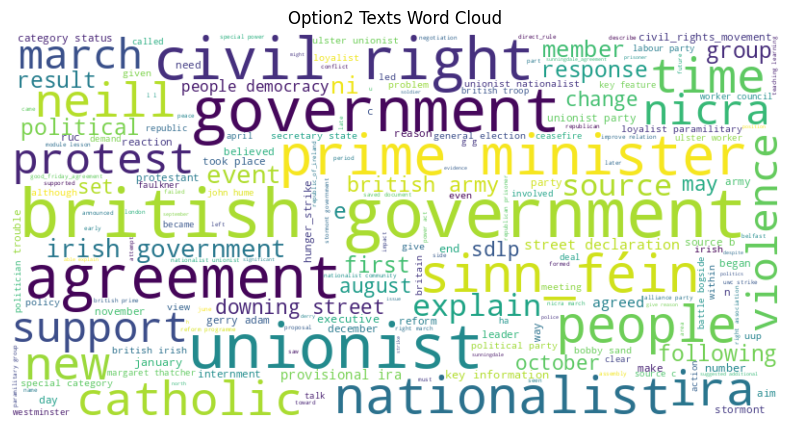

In [13]:
# Option2 word cloud
wc_option2 = WordCloud(width=800, height=400, background_color='white').generate(option2_text)
plt.figure(figsize=(10, 5))
plt.imshow(wc_option2, interpolation='bilinear')
plt.axis('off')
plt.title('Option2 Texts Word Cloud')
plt.show()

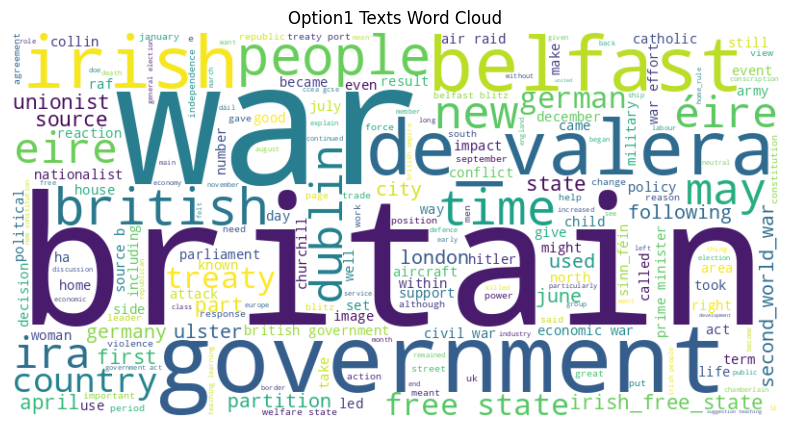

In [14]:
# Option1 word cloud
wc_option1 = WordCloud(width=800, height=400, background_color='white').generate(option1_text)
plt.figure(figsize=(10, 5))
plt.imshow(wc_option1, interpolation='bilinear')
plt.axis('off')
plt.title('Option1 Texts Word Cloud')
plt.show()

# TFIDF

In [15]:
# Debug: Check what's in the texts
print("\n=== DEBUG INFO ===")
if len(option2_text) > 0:
    print(f"Option2 text sample: {option2_text[:200]}")
    print(f"Option2 text length: {len(option2_text)}")
else:
    print("No Option2 text found!")

if len(option1_text) > 0:
    print(f"Option1 text sample: {option1_text[:200]}")
    print(f"Option1 text length: {len(option1_text)}")
else:
    print("No Option1 text found!")


=== DEBUG INFO ===
Option2 text sample: relation emergence development established government act act partitioned county southern later became irish_free_state population reacted new arrangement unionist mostly protestant delighted new stat
Option2 text length: 1336425
Option1 text sample: madden mcbride ccea gcse chapter page peace war neutrality britain second_world_war unit relation second_world_war background partition introduction saw significant change relationship britain british
Option1 text length: 760376


In [16]:
# Function to get top TF-IDF weighted n-grams
def get_top_tfidf_ngrams(text, ngram_range=(1, 1), top_n=20):
    """Get top n-grams based on TF-IDF scores"""
    
    vectorizer = TfidfVectorizer(max_features=1000, ngram_range=ngram_range)
    
    # Debug: check if we have any content
    print(f"Text length: {len(text)}")
    print(f"First 200 characters: {text[:200]}")
    
    # Check if text is mostly whitespace or empty
    if len(text.strip()) == 0:
        print("Warning: Text is empty or only whitespace!")
        return []
    
    try:
        tfidf_matrix = vectorizer.fit_transform([text])
        feature_names = vectorizer.get_feature_names_out()
        
        print(f"Number of features found: {len(feature_names)}")
        if len(feature_names) > 0:
            print(f"First 10 features: {feature_names[:10]}")
        
        if len(feature_names) == 0:
            print("Warning: No features found. Trying without stopwords...")
            vectorizer = TfidfVectorizer(max_features=1000, ngram_range=ngram_range)
            tfidf_matrix = vectorizer.fit_transform([text])
            feature_names = vectorizer.get_feature_names_out()
            print(f"Features without stopwords: {len(feature_names)}")
        
        # Get TF-IDF scores
        tfidf_sums = np.array(tfidf_matrix.sum(axis=0)).flatten()
        top_indices = tfidf_sums.argsort()[-top_n:][::-1]
        top_ngrams = [(feature_names[i], tfidf_sums[i]) for i in top_indices]
        return top_ngrams
        
    except ValueError as e:
        print(f"Error in TF-IDF processing: {e}")
        print("Trying without any stopwords...")
        vectorizer = TfidfVectorizer(max_features=1000, ngram_range=ngram_range)
        tfidf_matrix = vectorizer.fit_transform([text])
        feature_names = vectorizer.get_feature_names_out()
        
        # Get TF-IDF scores
        tfidf_sums = np.array(tfidf_matrix.sum(axis=0)).flatten()
        top_indices = tfidf_sums.argsort()[-top_n:][::-1]
        top_ngrams = [(feature_names[i], tfidf_sums[i]) for i in top_indices]
        return top_ngrams

In [17]:
# Analyze Option2 texts
print("\n=== OPTION2 TEXTS ANALYSIS ===")

# TF-IDF for unigrams
print("Building TF-IDF for Option2 texts...")
option2_top_terms = get_top_tfidf_ngrams(option2_text, ngram_range=(1, 1), top_n=30)

print("\nTop 30 terms in Option2 texts:")
for term, score in option2_top_terms:
    print(f"{term}: {score:.4f}")

# TF-IDF for bigrams
option2_top_bigrams = get_top_tfidf_ngrams(option2_text, ngram_range=(2, 2), top_n=30)

print("\nTop 30 bigrams in Option2 texts:")
for bigram, score in option2_top_bigrams:
    print(f"{bigram}: {score:.4f}")


=== OPTION2 TEXTS ANALYSIS ===
Building TF-IDF for Option2 texts...
Text length: 1336425
First 200 characters: relation emergence development established government act act partitioned county southern later became irish_free_state population reacted new arrangement unionist mostly protestant delighted new stat
Number of features found: 1000
First 10 features: ['able' 'accept' 'accepted' 'account' 'achieve' 'achieved' 'achieving'
 'across' 'act' 'action']

Top 30 terms in Option2 texts:
government: 0.2985
unionist: 0.2653
british: 0.2110
nationalist: 0.1710
ira: 0.1677
agreement: 0.1628
irish: 0.1377
people: 0.1361
party: 0.1359
source: 0.1347
march: 0.1250
violence: 0.1228
support: 0.1198
political: 0.1197
new: 0.1179
catholic: 0.1097
right: 0.1084
may: 0.1051
neill: 0.1026
group: 0.0982
minister: 0.0954
explain: 0.0881
council: 0.0873
key: 0.0873
civil: 0.0871
sinn_féin: 0.0818
nicra: 0.0813
army: 0.0802
information: 0.0801
protest: 0.0795
Text length: 1336425
First 200 characters: r

In [19]:
# Analyze Option1 texts
print("\n=== OPTION1 TEXTS ANALYSIS ===")

# TF-IDF for unigrams
print("Building TF-IDF for Option1 texts...")
option1_top_terms = get_top_tfidf_ngrams(option1_text, ngram_range=(1, 1), top_n=30)

print("\nTop 30 terms in Option1 texts:")
for term, score in option1_top_terms:
    print(f"{term}: {score:.4f}")

# TF-IDF for bigrams
option1_top_bigrams = get_top_tfidf_ngrams(option1_text, ngram_range=(2, 2), top_n=30)

print("\nTop 30 bigrams in Option1 texts:")
for bigram, score in option1_top_bigrams:
    print(f"{bigram}: {score:.4f}")


=== OPTION1 TEXTS ANALYSIS ===
Building TF-IDF for Option1 texts...
Text length: 760376
First 200 characters: madden mcbride ccea gcse chapter page peace war neutrality britain second_world_war unit relation second_world_war background partition introduction saw significant change relationship britain british
Number of features found: 1000
First 10 features: ['ability' 'able' 'abolished' 'accept' 'accepted' 'according' 'account'
 'across' 'act' 'action']

Top 30 terms in Option1 texts:
war: 0.3573
irish: 0.3140
britain: 0.2649
government: 0.2460
british: 0.2286
belfast: 0.1656
state: 0.1596
people: 0.1508
de_valera: 0.1432
source: 0.1418
treaty: 0.1274
éire: 0.1058
new: 0.1001
dublin: 0.0906
act: 0.0889
time: 0.0873
ira: 0.0807
neutrality: 0.0756
german: 0.0750
free: 0.0747
eire: 0.0742
unionist: 0.0731
country: 0.0731
minister: 0.0715
may: 0.0704
nationalist: 0.0685
part: 0.0655
irish_free_state: 0.0644
economic: 0.0638
second_world_war: 0.0633
Text length: 760376
First 200 character